<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)


# Display the first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
# Write your code here
print('Columns :', df.columns,
      'Types :', df.dtypes, 
      'Shape :', df.shape, 
      'Missing Val :', df.isnull().sum())

Columns : Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114) Types : ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object Shape : (65437, 114) Missing Val : ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11    

<h5>2.2 Generate basic statistics for numerical columns.</h5>


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>
<h5> 3.1 Определите несоответствующие или неуместные записи в конкретных столбцах (например, Страна).¶</h5>

In [4]:
countries = [
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize",
    "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Brunei", "Bulgaria", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad",
    "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Côte d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
    "Denmark", "Djibouti", "Dominica", "Dominican Republic",
    "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia",
    "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France",
    "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada",
    "Guatemala", "Guinea", "Guinea-Bissau", "Guyana",
    "Haiti", "Honduras", "Hungary",
    "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy",
    "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan",
    "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg",
    "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta",
    "Marshall Islands", "Mauritania", "Mauritius", "Mexico", "Micronesia",
    "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua",
    "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway",
    "Oman",
    "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal",
    "Qatar",
    "Romania", "Russian Federation", "Rwanda",
    "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
    "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Solomon Islands", "Somalia", "South Africa", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom of Great Britain and Northern Ireland", "United States of America",
    "Uruguay", "Uzbekistan",
    "Vanuatu", "Vatican City", "Venezuela", "Vietnam",
    "Yemen",
    "Zambia", "Zimbabwe",
    "Holy See", "Palestine", 'kosovo', 'taiwan', 
]

In [5]:
# Write your code here
df['country_clean'] = (
    df['Country']
    .astype(str)
    .str.strip()
    .str.lower()
)

all_countries_clean = [c.strip().lower() for c in countries]


In [6]:
invalid_countries = df.loc[~df['country_clean'].isin(all_countries_clean), 'country_clean']

In [7]:
new_list = {'iran, islamic republic of...' : 'iran',
             'republic of north macedonia' : 'macedonia',
             'united republic of tanzania' : 'tanzania',
             'viet nam' : 'vietnam',
             'venezuela, bolivarian republic of...': 'venezuela',
             'republic of korea' : 'south korea',
             'republic of moldova' : 'moldova', 
             'hong kong (s.a.r.)' : 'china', 
             "lao people's democratic republic" : 'laos', 
             'democratic republic of the congo' : 'congo', 
             'syrian arab republic' : 'syria',
             'swaziland' : 'eswatini', 
             "democratic people's republic of korea" : 'north korea',
             'congo, republic of the...' : 'congo', 
             'libyan arab jamahiriya' : 'lybia',
             'cape verde' : 'cabo verde', 
             'brunei darussalam' : 'brunei',
             'micronesia, federated states of...' : 'micronesia',
             'macedonia' : 'north macedonia'}


<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [8]:
df['country_clean'] = df['country_clean'].replace(new_list)

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [9]:
df['Employment'].unique()
df_encoded = df['Employment'].str.get_dummies(sep=';')
df_encoded.head()

,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [10]:
df.isnull().sum().sort_values(ascending = False)

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
Age                               0
Check                             0
MainBranch                        0
Employment                        0
ResponseId                        0
Length: 115, dtype: int64

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [11]:
## Write your code here
median = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median)

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [12]:
## Write your code here
freq = df['RemoteWork'].value_counts().idxmax()
df['RemoteWork'] = df['RemoteWork'].fillna(freq)

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [13]:
up=df['ConvertedCompYearly'].quantile(0.99)
down=df['ConvertedCompYearly'].quantile(0.01)
df=df[(df['ConvertedCompYearly'] <= up)&(df['ConvertedCompYearly'] >= down)]

In [14]:
## Write your code here
df['min_max_conv'] = (df['ConvertedCompYearly']-df['ConvertedCompYearly'].min())/(df['ConvertedCompYearly'].max()-df['ConvertedCompYearly'].min())
df['min_max_conv'].head()

0    0.256084
1    0.256084
2    0.256084
3    0.256084
4    0.256084
Name: min_max_conv, dtype: float64

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [15]:
## Write your code here
df['Log_ConvertedCompYearly'] = np.log(df['ConvertedCompYearly'] + 1)

Text(0.5, 1.0, 'Distribution of Yearly Compensation')

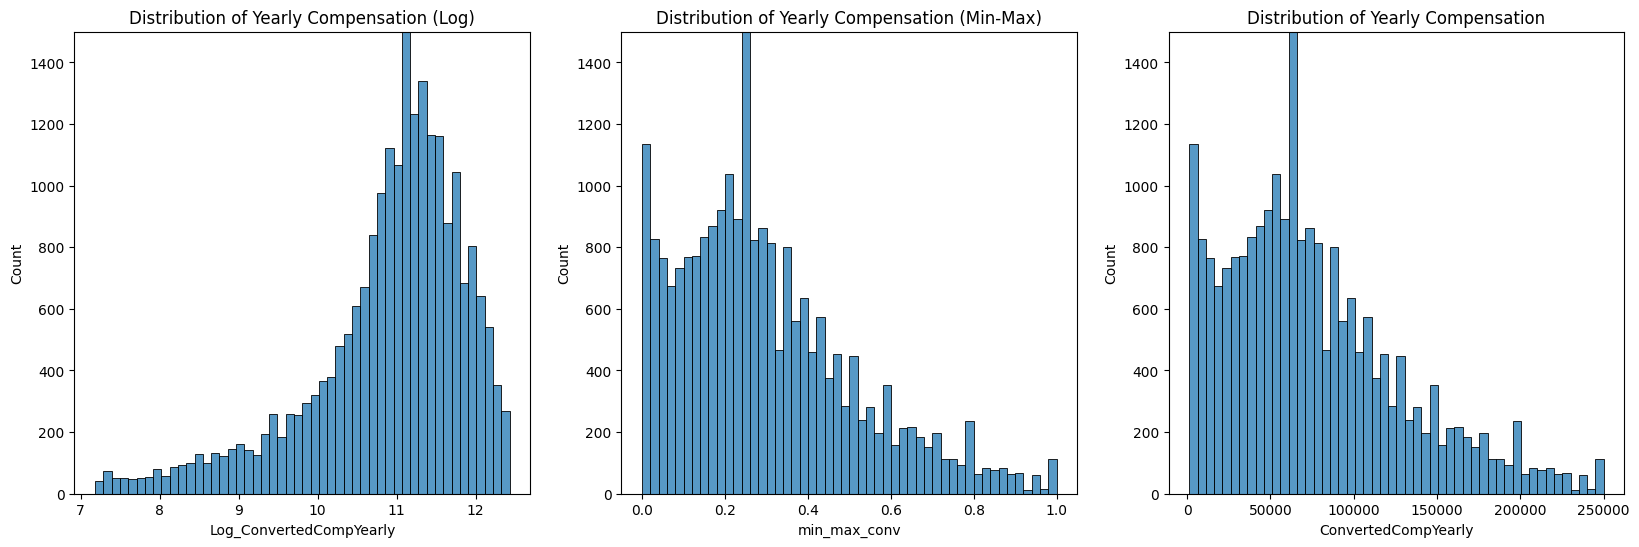

In [20]:
fig = plt.figure(figsize=(20,6))
ax1=fig.add_subplot(1,3,1)
sns.histplot(data=df, x = 'Log_ConvertedCompYearly', bins = 50, ax = ax1)
ax1.set_ylim(0, 1500)
ax1.set_title('Distribution of Yearly Compensation (Log)')

ax2 = fig.add_subplot(1,3,2)
sns.histplot(data=df, x = 'min_max_conv', bins= 50, ax= ax2)
ax2.set_ylim(0, 1500)
ax2.set_title('Distribution of Yearly Compensation (Min-Max)')

ax3 = fig.add_subplot(1,3,3)
sns.histplot(data=df, x = 'ConvertedCompYearly', bins= 50, ax = ax3)
ax3.set_ylim(0, 1500)
ax3.set_title('Distribution of Yearly Compensation')

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.



Copyright © IBM Corporation. All rights reserved.
